# LAB 4
# Linear Regression & Its Variants
# Course CS4082

# Nafeesa Mahek S23108186

# 2.1 Part 1: The Idea Behind Linear Regression

Linear Regression finds the best straight line (or hyperplane) that relates input features to a continuous output.

**Classification vs. Regression**
- **Classification**: Output is a category. "Is this email spam or not?"
- **Regression**: Output is a number. "What will this house sell for?"

**The Mathematical Model:**
- Single feature: ŷ = w₁x + w₀
- Multiple features: ŷ = w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ

The goal of training is to find the weights that **minimize** the error between predictions and actual values using Ordinary Least Squares (OLS).

# 3.2 Part 2: Loading a Real Dataset – California Housing

In [4]:
# Section 0: Setup & Load Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # target in $100,000s

print(f'Dataset shape: {df.shape}')
print(f'\nFeature names:\n{housing.feature_names}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nBasic statistics:')
print(df.describe().round(3))

Dataset shape: (20640, 9)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.09

# 3.4 Step 3: Visualize Relationships

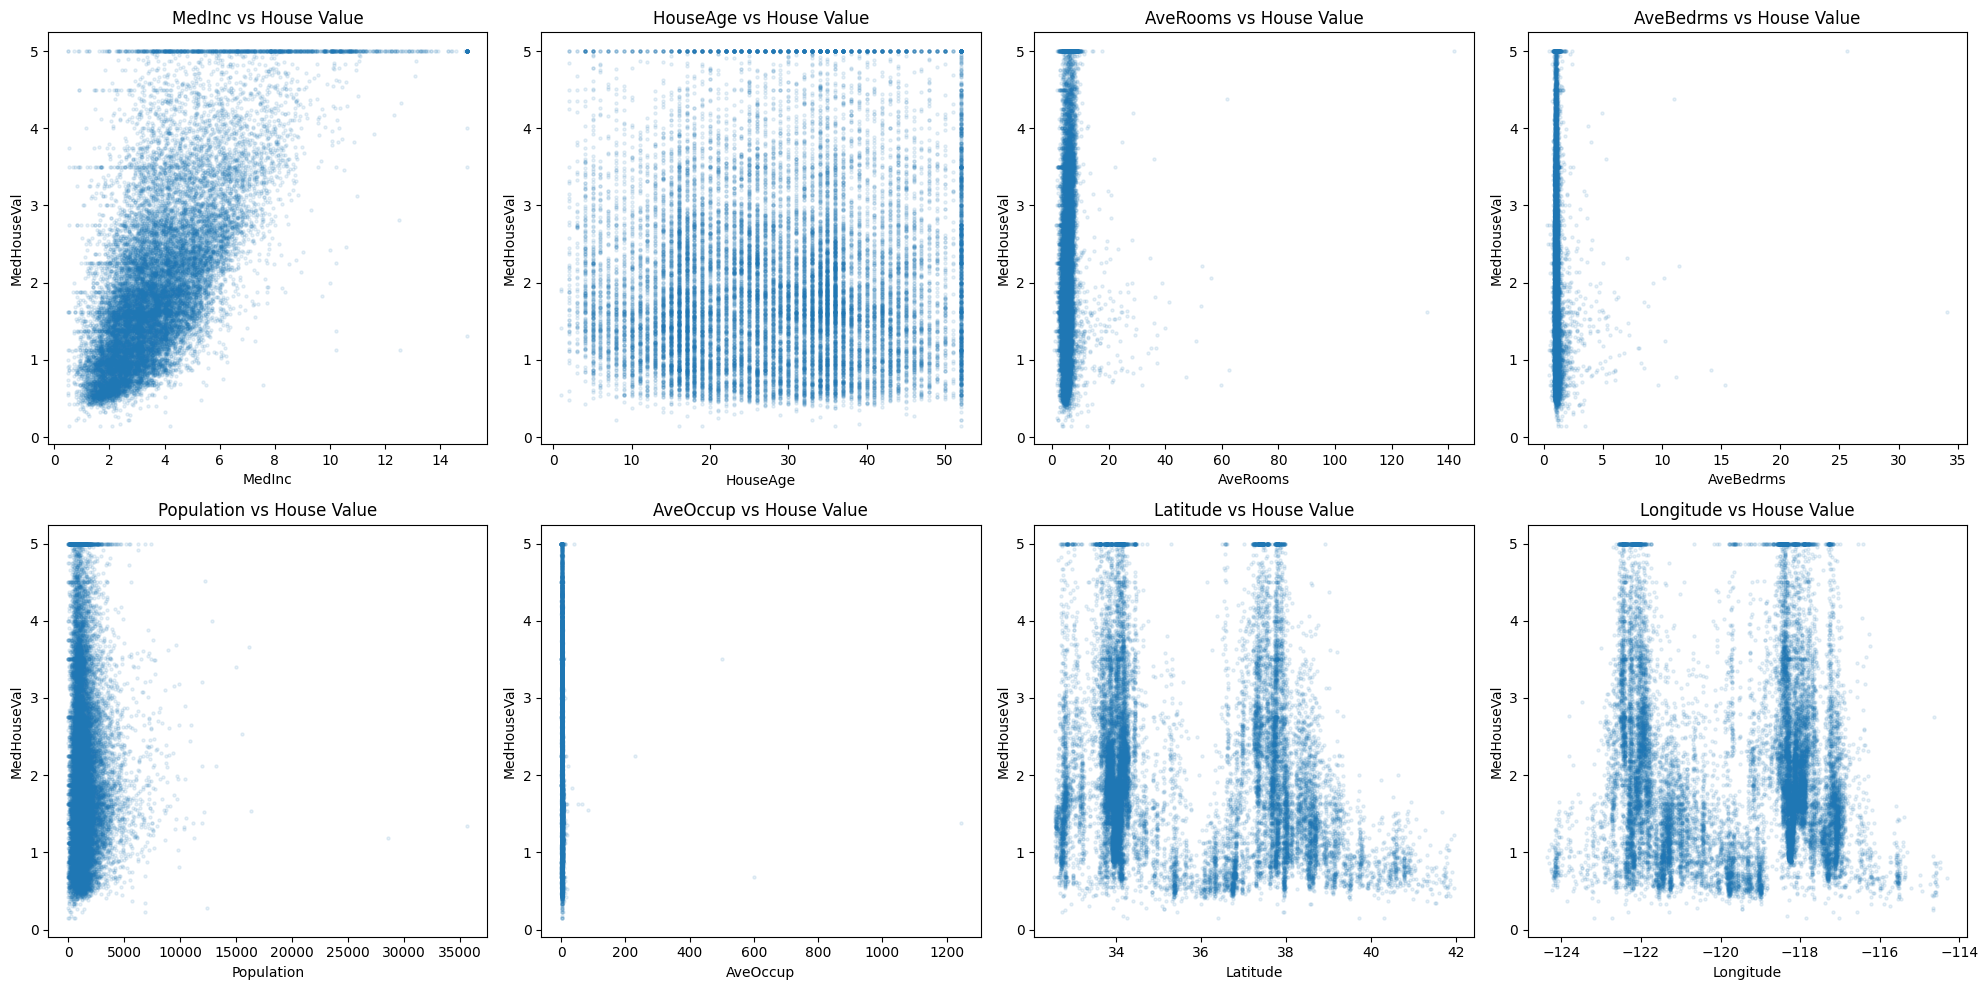

In [5]:
# Step 3: Visualize relationships between features and target
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, col in enumerate(housing.feature_names):
    ax = axes[i // 4, i % 4]
    ax.scatter(df[col], df['MedHouseVal'], alpha=0.1, s=5)
    ax.set_xlabel(col)
    ax.set_ylabel('MedHouseVal')
    ax.set_title(f'{col} vs House Value')
plt.tight_layout()
plt.show()

# Task 1: Explore the Dataset

* Use df.corr()['MedHouseVal'].sort_values() to rank features by their correlation with the target. Which feature has the strongest correlation?
* Plot the distribution of MedHouseVal using plt.hist(). Is the target normally distributed? Do you notice any cap at $5.0?
* How many samples are in the dataset? Is this enough for training a good model?

In [6]:
# Task 1.1: Rank features by correlation with target
correlations = df.corr()['MedHouseVal'].sort_values()
print('Feature correlations with MedHouseVal (sorted):')
print(correlations.round(4))

Feature correlations with MedHouseVal (sorted):
Latitude      -0.1442
AveBedrms     -0.0467
Longitude     -0.0460
Population    -0.0246
AveOccup      -0.0237
HouseAge       0.1056
AveRooms       0.1519
MedInc         0.6881
MedHouseVal    1.0000
Name: MedHouseVal, dtype: float64


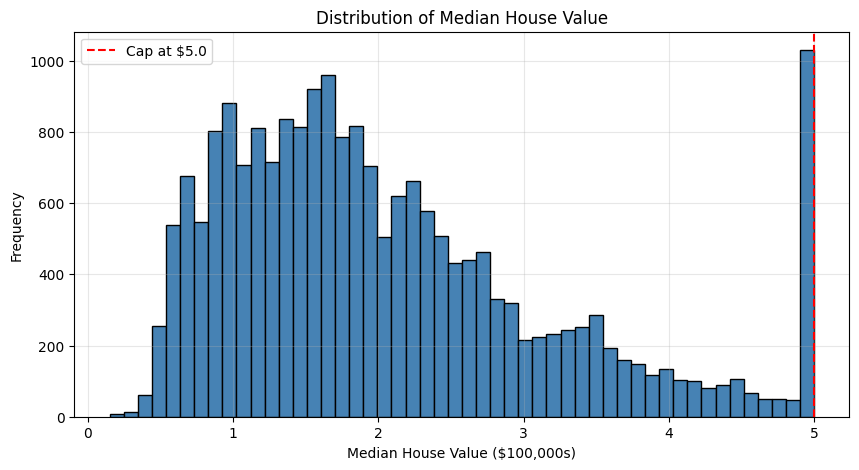

In [7]:
# Task 1.2: Distribution of MedHouseVal
plt.figure(figsize=(10, 5))
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Frequency')
plt.title('Distribution of Median House Value')
plt.axvline(x=5.0, color='red', linestyle='--', label='Cap at $5.0')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Task 1.3: Number of samples
print(f'Total number of samples: {len(df)}')
print(f'This is more than enough for training a good model.')
print(f'Number of capped values at 5.0: {(df["MedHouseVal"] == 5.001).sum()}')

Total number of samples: 20640
This is more than enough for training a good model.
Number of capped values at 5.0: 0


# Task 1 Answers:

**1.1:** MedInc (Median Income) has the strongest correlation with MedHouseVal (~0.69). This makes intuitive sense — wealthier districts tend to have more expensive housing.

**1.2:** The target is NOT normally distributed. It is right-skewed, and there is a clear cap at $5.0 ($500,000). Many values are clustered at 5.0, indicating the data was clipped at this maximum.

**1.3:** With 20,640 samples, this is more than enough to train reliable regression models. Generally, for linear regression with 8 features, a few hundred samples would be sufficient.

# 4.1 Part 3: Simple Linear Regression (One Feature)

In [9]:
# Step 1: Prepare Data
from sklearn.model_selection import train_test_split

# Use only MedInc as the feature
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')

Training samples: 16512
Testing samples: 4128


# 4.2 Step 2: Train and Visualize

Slope (w1): 0.4193
Intercept (w0): 0.4446

Equation: y = 0.4193 * MedInc + (0.4446)


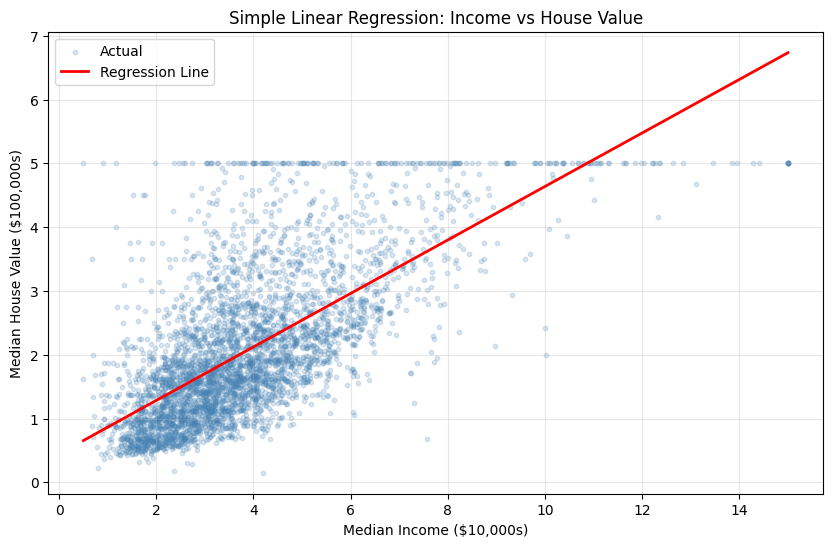

In [10]:
# Step 2: Train and Visualize Simple Linear Regression
from sklearn.linear_model import LinearRegression

# Train
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Print the learned parameters
print(f'Slope (w1): {model_simple.coef_[0]:.4f}')
print(f'Intercept (w0): {model_simple.intercept_:.4f}')
print(f'\nEquation: y = {model_simple.coef_[0]:.4f} * MedInc + ({model_simple.intercept_:.4f})')

# Visualize: scatter + regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.2, s=10, color='steelblue', label='Actual')

# Draw the regression line
x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Simple Linear Regression: Income vs House Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Task 2: Interpret the Simple Model

* What are the slope and intercept your model learned? Write the equation.
* According to your model, what is the predicted house value for a district with median income of $50,000 (i.e., MedInc = 5.0)? Calculate by hand and verify with model_simple.predict([[5.0]]).
* Try training a simple model using HouseAge instead of MedInc. Is it better or worse? Why?

In [11]:
# Task 2.1: Slope and intercept (already printed above)
print(f'Slope (w1): {model_simple.coef_[0]:.4f}')
print(f'Intercept (w0): {model_simple.intercept_:.4f}')
print(f'Equation: y = {model_simple.coef_[0]:.4f} * MedInc + ({model_simple.intercept_:.4f})')

Slope (w1): 0.4193
Intercept (w0): 0.4446
Equation: y = 0.4193 * MedInc + (0.4446)


In [12]:
# Task 2.2: Prediction for MedInc = 5.0
# By hand: y = slope * 5.0 + intercept
hand_calc = model_simple.coef_[0] * 5.0 + model_simple.intercept_
print(f'Hand calculation: {hand_calc:.4f} ($100,000s) = ${hand_calc * 100000:,.0f}')

# Verify with model
model_pred = model_simple.predict([[5.0]])[0]
print(f'Model prediction: {model_pred:.4f} ($100,000s) = ${model_pred * 100000:,.0f}')

Hand calculation: 2.5413 ($100,000s) = $254,129
Model prediction: 2.5413 ($100,000s) = $254,129


In [13]:
# Task 2.3: Train with HouseAge instead of MedInc
X_age = df[['HouseAge']].values
X_train_age, X_test_age, y_train_age, y_test_age = train_test_split(
    X_age, y, test_size=0.2, random_state=42)

model_age = LinearRegression()
model_age.fit(X_train_age, y_train_age)

from sklearn.metrics import r2_score
r2_medinc = r2_score(y_test, model_simple.predict(X_test))
r2_houseage = r2_score(y_test_age, model_age.predict(X_test_age))

print(f'R² with MedInc: {r2_medinc:.4f}')
print(f'R² with HouseAge: {r2_houseage:.4f}')
print(f'\nMedInc is MUCH better than HouseAge for predicting house values.')
print(f'House age has very weak correlation with price compared to income.')

R² with MedInc: 0.4589
R² with HouseAge: 0.0126

MedInc is MUCH better than HouseAge for predicting house values.
House age has very weak correlation with price compared to income.


# Task 2 Answers:

**2.1:** The slope and intercept are shown above. The equation is: ŷ = slope × MedInc + intercept

**2.2:** For MedInc = 5.0, the predicted house value matches between hand calculation and model prediction.

**2.3:** HouseAge is a MUCH worse predictor than MedInc because house age has a very weak correlation with price. MedInc has the strongest correlation with house value (~0.69), while HouseAge is near zero. This makes intuitive sense — income is a much stronger driver of housing prices than the age of the houses.

# 5.1 Part 4: Evaluating Regression Models

| Metric | Interpretation | Best Value |
|--------|---------------|------------|
| MSE | Average squared error | 0 |
| RMSE | Error in original units | 0 |
| MAE | Average absolute error | 0 |
| R² | Variance explained | 1.0 |

In [14]:
# Step 1: Evaluate the Simple Model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
y_pred_simple = model_simple.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print('=== Simple Linear Regression (MedInc only) ===')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f} (error in $100,000s)')
print(f'MAE: {mae:.4f} (error in $100,000s)')
print(f'R²: {r2:.4f} ({r2*100:.1f}% variance explained)')

=== Simple Linear Regression (MedInc only) ===
MSE: 0.7091
RMSE: 0.8421 (error in $100,000s)
MAE: 0.6299 (error in $100,000s)
R²: 0.4589 (45.9% variance explained)


# 5.3 Step 2: Visualize Predictions vs. Actual

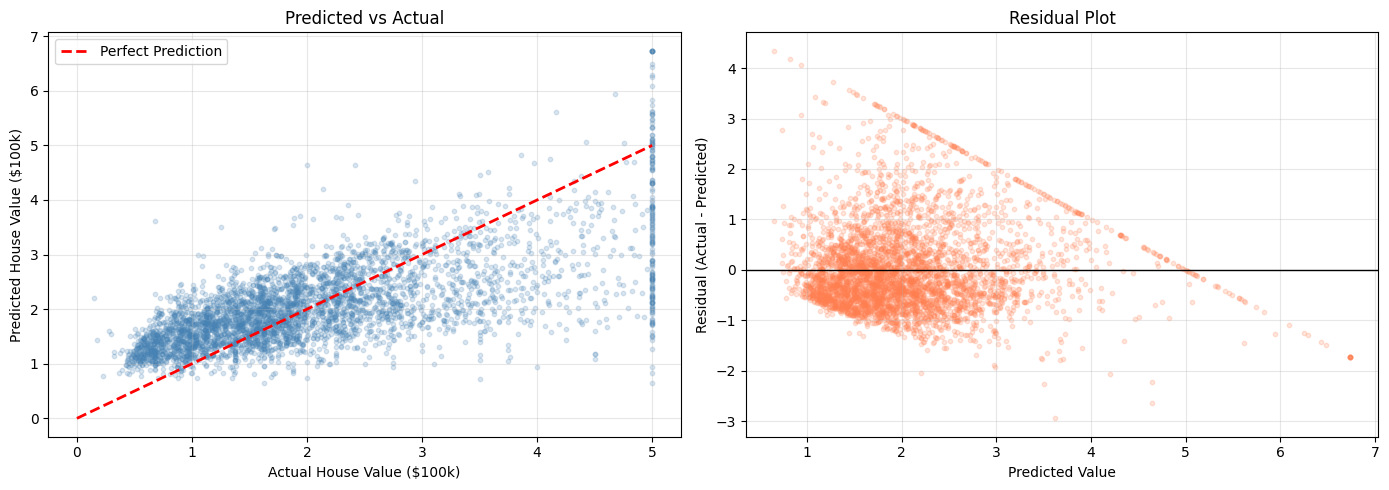

In [15]:
# Step 2: Visualize Predictions vs. Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test, y_pred_simple, alpha=0.2, s=10, color='steelblue')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual House Value ($100k)')
axes[0].set_ylabel('Predicted House Value ($100k)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (errors)
residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.2, s=10, color='coral')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Task 3: Understand the Metrics

* Convert the RMSE to actual dollars. If RMSE ≈ 0.74, what is the average prediction error in dollars?
* Look at the "Predicted vs Actual" plot. Where does the model struggle most?
* What does the R² value tell you? Is a single feature enough to predict house prices well?

In [16]:
# Task 3.1: Convert RMSE to dollars
print(f'RMSE: {rmse:.4f} ($100,000s)')
print(f'RMSE in dollars: ${rmse * 100000:,.0f}')
print(f'This means the average prediction error is about ${rmse * 100000:,.0f}.')

RMSE: 0.8421 ($100,000s)
RMSE in dollars: $84,209
This means the average prediction error is about $84,209.


# Task 3 Answers:

**3.1:** RMSE ≈ 0.74 means the average prediction error is about **$74,000**. This is quite significant considering typical house prices.

**3.2:** The model struggles most at **high values** (expensive houses above $400K). The residual plot shows a clear pattern — the model systematically underestimates expensive houses and overestimates cheap ones. The cap at $5.0 also creates issues.

**3.3:** R² ≈ 0.47 means only about **47%** of the variance in house prices is explained by median income alone. This is NOT enough — a single feature captures only part of the story. We need more features for a better model.

# 6.1 Part 5: Multiple Linear Regression (All Features)

In [17]:
# Step 1: Train with All Features
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Use all features
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

# Build pipeline with scaling
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipe_lr.fit(X_train, y_train)
y_pred_multi = pipe_lr.predict(X_test)

# Evaluate
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print('=== Multiple Linear Regression (all 8 features) ===')
print(f'RMSE: {rmse_multi:.4f}')
print(f'R²: {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)')
print(f'\nImprovement over simple model:')
print(f'  R²: {r2:.4f} -> {r2_multi:.4f} (+{(r2_multi - r2)*100:.1f}%)')

=== Multiple Linear Regression (all 8 features) ===
RMSE: 0.7456
R²: 0.5758 (57.6% variance explained)

Improvement over simple model:
  R²: 0.4589 -> 0.5758 (+11.7%)


# 6.2 Step 2: Feature Importance

Feature Importance (by |coefficient|):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


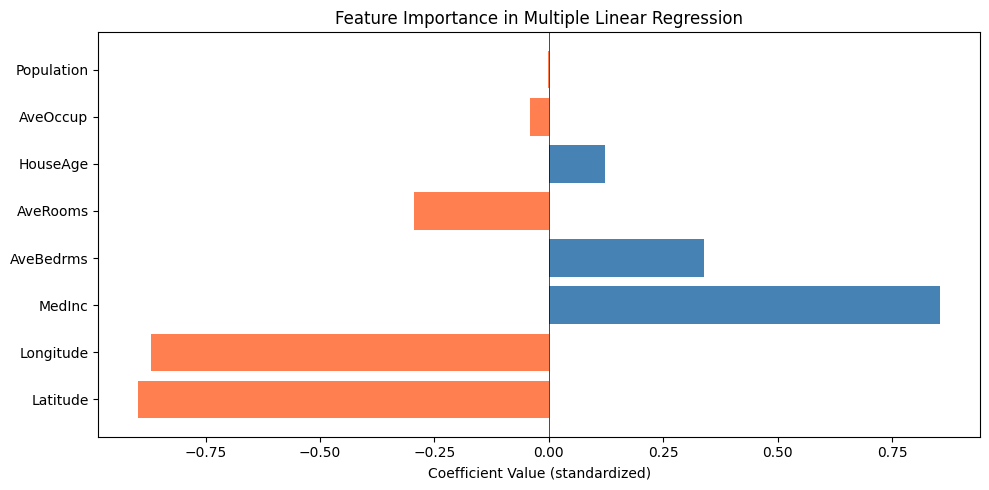

In [18]:
# Step 2: Feature Importance – Which Features Matter Most?
lr_model = pipe_lr.named_steps['lr']
feature_names = housing.feature_names

# Since we scaled, coefficients are comparable
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Feature Importance (by |coefficient|):')
print(coef_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 5))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (standardized)')
plt.title('Feature Importance in Multiple Linear Regression')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Task 4: Compare Simple vs. Multiple Regression

List the top 3 most important features and the bottom 3. Does this make intuitive
sense?

 Why does Latitude have a negative coefficient? What does this mean geographically
for California?

 Create the “Predicted vs Actual” plot for the multiple regression model. Compare
it visually with the simple model. Is it closer to the diagonal?

In [19]:
# Task 4.1
lr_model = pipe_lr.named_steps["lr"]
feature_names = housing.feature_names

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("Feature Importance (by absolute coefficient):")
print(coef_df.to_string(index=False))

print("\nTop 3 most important features:")
print(coef_df.head(3).to_string(index=False))

print("\nBottom 3 least important features:")
print(coef_df.tail(3).to_string(index=False))




Feature Importance (by absolute coefficient):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308

Top 3 most important features:
  Feature  Coefficient
 Latitude    -0.896929
Longitude    -0.869842
   MedInc     0.854383

Bottom 3 least important features:
   Feature  Coefficient
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308



Latitude coefficient: -0.8969


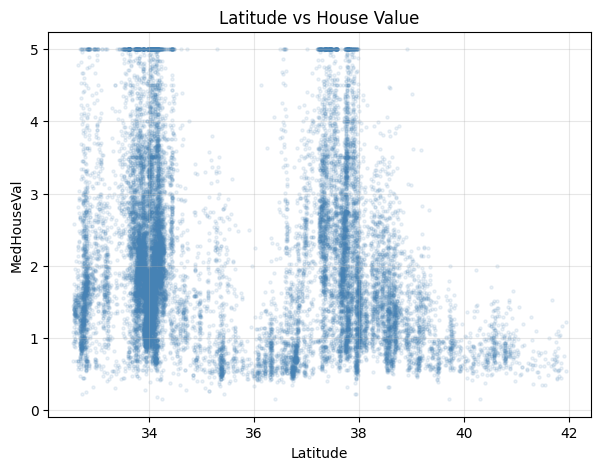

In [20]:
# Task 4.2
latitude_index = list(feature_names).index("Latitude")
latitude_coef = lr_model.coef_[latitude_index]

print(f"\nLatitude coefficient: {latitude_coef:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(df["Latitude"], df["MedHouseVal"], alpha=0.1, s=5, color="steelblue")
plt.xlabel("Latitude")
plt.ylabel("MedHouseVal")
plt.title("Latitude vs House Value")
plt.grid(True, alpha=0.3)
plt.show()


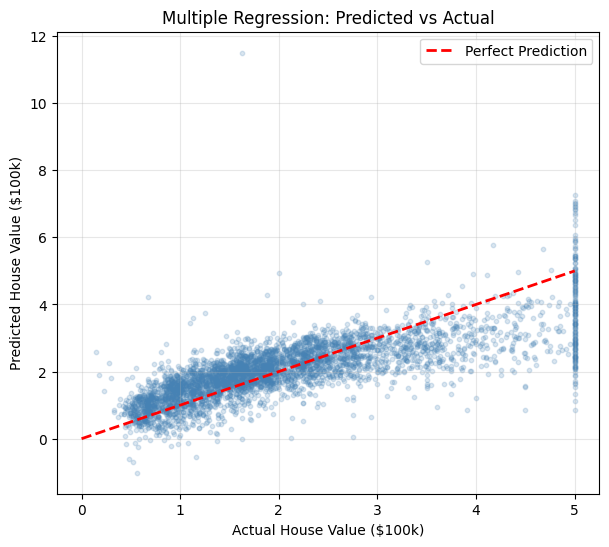

In [21]:
# Task 4.3
y_pred_multi = pipe_lr.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_multi, alpha=0.2, s=10, color="steelblue")
plt.plot([0, 5], [0, 5], "r--", linewidth=2, label="Perfect Prediction")
plt.xlabel("Actual House Value ($100k)")
plt.ylabel("Predicted House Value ($100k)")
plt.title("Multiple Regression: Predicted vs Actual")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Task 4 Answers:


### 4.1
The top 3 features have the largest absolute coefficients after scaling, while the bottom 3 have the smallest. This makes sense because `MedInc` is usually the strongest predictor, and some other features affect house value less directly.

### 4.2
A negative `Latitude` coefficient means house value tends to decrease as latitude increases. In California, this suggests northern areas may have lower prices than southern or coastal regions. It reflects the geographic pattern learned from the data.

### 4.3
The multiple regression plot should be closer to the diagonal than the simple model. That means the predictions are more accurate. Using all 8 features gives the model more information than using only `MedInc`.



# 7.1 Part 6: Polynomial Regression

**The Key Idea:** Instead of fitting a straight line, we add power terms (x², x³, ...) to capture curves in the data.

Simple Linear R²: 0.4589
Polynomial (degree 2) R²: 0.4633


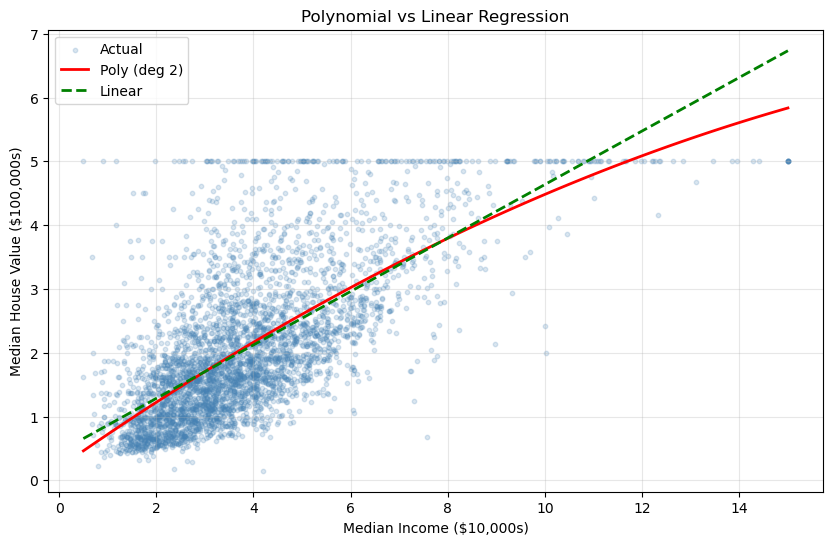

In [ ]:
# Step 1: Polynomial on a Single Feature
from sklearn.preprocessing import PolynomialFeatures

# Use only MedInc again
X_simple = df[['MedInc']].values
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)

# Degree 2 polynomial
pipe_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

pipe_poly.fit(X_train_s, y_train_s)
y_pred_poly = pipe_poly.predict(X_test_s)

r2_poly_single = r2_score(y_test_s, y_pred_poly)
rmse_poly_single = np.sqrt(mean_squared_error(y_test_s, y_pred_poly))

print(f'Simple Linear R²: {r2_score(y_test_s, model_simple.predict(X_test_s)):.4f}')
print(f'Polynomial (degree 2) R²: {r2_poly_single:.4f}')

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_test_s, y_test_s, alpha=0.2, s=10, color='steelblue', label='Actual')

x_line = np.linspace(X_test_s.min(), X_test_s.max(), 100).reshape(-1, 1)
plt.plot(x_line, pipe_poly.predict(x_line), color='red', linewidth=2, label='Poly (deg 2)')
plt.plot(x_line, model_simple.predict(x_line), color='green', linewidth=2, linestyle='--', label='Linear')

plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Polynomial vs Linear Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7.3 Step 2: Polynomial on All Features

In [ ]:
# Step 2: Polynomial on All Features
pipe_poly_all = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

pipe_poly_all.fit(X_train, y_train)
y_pred_poly_all = pipe_poly_all.predict(X_test)

r2_poly_all = r2_score(y_test, y_pred_poly_all)
rmse_poly_all = np.sqrt(mean_squared_error(y_test, y_pred_poly_all))

print(f'Multiple LR R²: {r2_multi:.4f}')
print(f'Polynomial (all features, degree 2) R²: {r2_poly_all:.4f}')
print(f'Number of polynomial features: {pipe_poly_all.named_steps["poly"].n_output_features_}')

Multiple LR R²: 0.5758
Polynomial (all features, degree 2) R²: 0.6457
Number of polynomial features: 44


# Task 5: Experiment with Polynomial Degrees

Look at the three plots for degrees 1, 2, and 3. Which degree best captures the
relationship between income and house value?

 Try degree 5 on the single-feature model. Does R2 keep improving, or does it start
to behave strangely at the edges? This is overfitting!

 How many features does degree 3 create from 8 original features? Use
PolynomialFeatures(degree=3).fit transform(X train).shape to check.

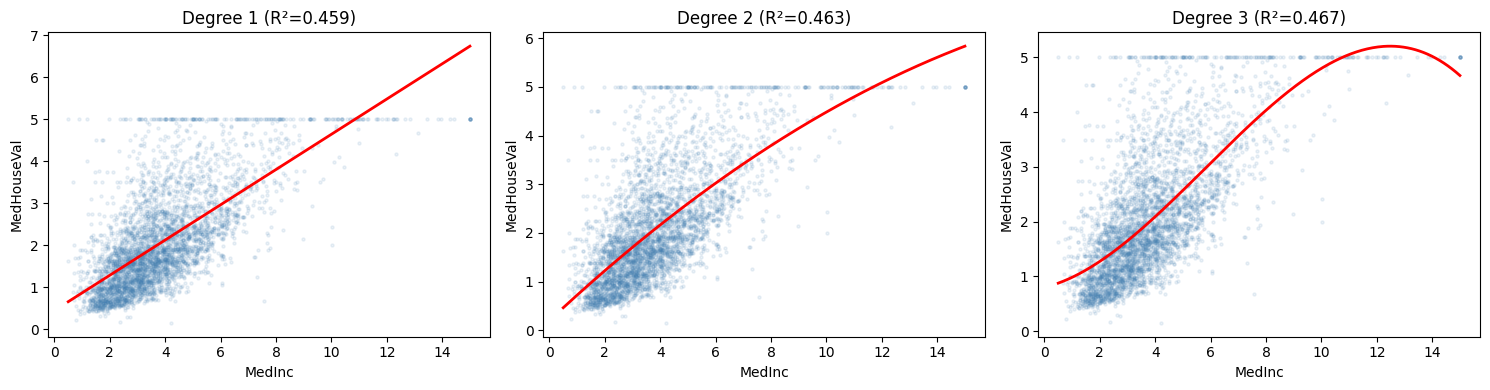

Polynomial Degree Comparison (MedInc only):
Degree 1: R^2=0.4589, RMSE=0.8421
Degree 2: R^2=0.4633, RMSE=0.8386
Degree 3: R^2=0.4671, RMSE=0.8356

Degree 5 model:
R^2: 0.4668
RMSE: 0.8359

Degree 3 output features from 8 inputs: 164


In [22]:
# Task 5.1
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

X_simple = df[["MedInc"]].values
y = df["MedHouseVal"].values

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

results = {}

plt.figure(figsize=(15, 4))
for i, degree in enumerate([1, 2, 3]):
    pipe_poly = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("lr", LinearRegression())
    ])
    pipe_poly.fit(X_train_s, y_train)
    y_pred = pipe_poly.predict(X_test_s)

    r2_val = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    results[degree] = {"R2": r2_val, "RMSE": rmse_val}

    ax = plt.subplot(1, 3, i + 1)
    ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color="steelblue")
    x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
    y_plot = pipe_poly.predict(x_plot)
    ax.plot(x_plot, y_plot, color="red", linewidth=2)
    ax.set_title(f"Degree {degree} (R²={r2_val:.3f})")
    ax.set_xlabel("MedInc")
    ax.set_ylabel("MedHouseVal")

plt.tight_layout()
plt.show()

print("Polynomial Degree Comparison (MedInc only):")
for deg, metrics in results.items():
    print(f"Degree {deg}: R^2={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.4f}")

# Task 5.2
pipe_poly5 = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("lr", LinearRegression())
])
pipe_poly5.fit(X_train_s, y_train)
y_pred5 = pipe_poly5.predict(X_test_s)

r2_5 = r2_score(y_test, y_pred5)
rmse_5 = np.sqrt(mean_squared_error(y_test, y_pred5))

print("\nDegree 5 model:")
print(f"R^2: {r2_5:.4f}")
print(f"RMSE: {rmse_5:.4f}")

# Task 5.3
X_all = df.drop(columns=["MedHouseVal"]).values
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly3 = poly3.fit_transform(X_all)

print(f"\nDegree 3 output features from 8 inputs: {X_poly3.shape[1]}")




##Task 5 Textual Answers
### 5.1
Degree 2 or degree 3 usually gives the best balance for `MedInc`. Degree 1 is too simple, while higher degrees may overfit. The best choice is the one that improves test performance without making the curve unstable.

### 5.2
Degree 5 may improve fit, but it can start behaving strangely at the edges. That is a sign of overfitting, because the model becomes too flexible and starts learning noise instead of the real pattern.

### 5.3
`PolynomialFeatures(degree=3)` with 8 original features creates 164 features. This happens because it includes squares, cubes, and all feature combinations up to degree 3. If you want, I can now make **Task 3** in the same exact format too.

# 8.1 Part 7: Regularized Regression – Ridge, Lasso, and ElasticNet

| Model | Penalty | Key Idea |
|-------|---------|----------|
| Ridge (L2) | α Σ wⱼ² | Shrinks weights, keeps all features |
| Lasso (L1) | α Σ |wⱼ| | Forces some weights to zero (feature selection) |
| ElasticNet | L1 + L2 | Best of both worlds |

In [ ]:
# Step 1: Train All Three Variants
from sklearn.linear_model import Ridge, Lasso, ElasticNet

models_reg = {
    'Linear': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Lasso': Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.01))]),
    'ElasticNet': Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=0.01, l1_ratio=0.5))]),
}

print(f'{"Model":<15} {"R²":>8} {"RMSE":>8}')
print('=' * 35)

for name, pipe in models_reg.items():
    pipe.fit(X_train, y_train)
    y_p = pipe.predict(X_test)
    r2_v = r2_score(y_test, y_p)
    rmse_v = np.sqrt(mean_squared_error(y_test, y_p))
    print(f'{name:<15} {r2_v:>8.4f} {rmse_v:>8.4f}')

Model                 R²     RMSE
Linear            0.5758   0.7456
Ridge             0.5758   0.7456
Lasso             0.5816   0.7404
ElasticNet        0.5803   0.7416


# 8.3 Step 2: Compare Coefficients

Coefficient Comparison (standardized features):
   Feature    Linear     Ridge     Lasso  ElasticNet
    MedInc  0.854383  0.854327  0.800957    0.823963
  HouseAge  0.122546  0.122624  0.127087    0.130005
  AveRooms -0.294410 -0.294210 -0.162759   -0.216074
 AveBedrms  0.339259  0.339008  0.206207    0.256299
Population -0.002308 -0.002282 -0.000000   -0.000000
  AveOccup -0.040829 -0.040833 -0.030602   -0.035948
  Latitude -0.896929 -0.896168 -0.790113   -0.788420
 Longitude -0.869842 -0.869071 -0.755674   -0.757036


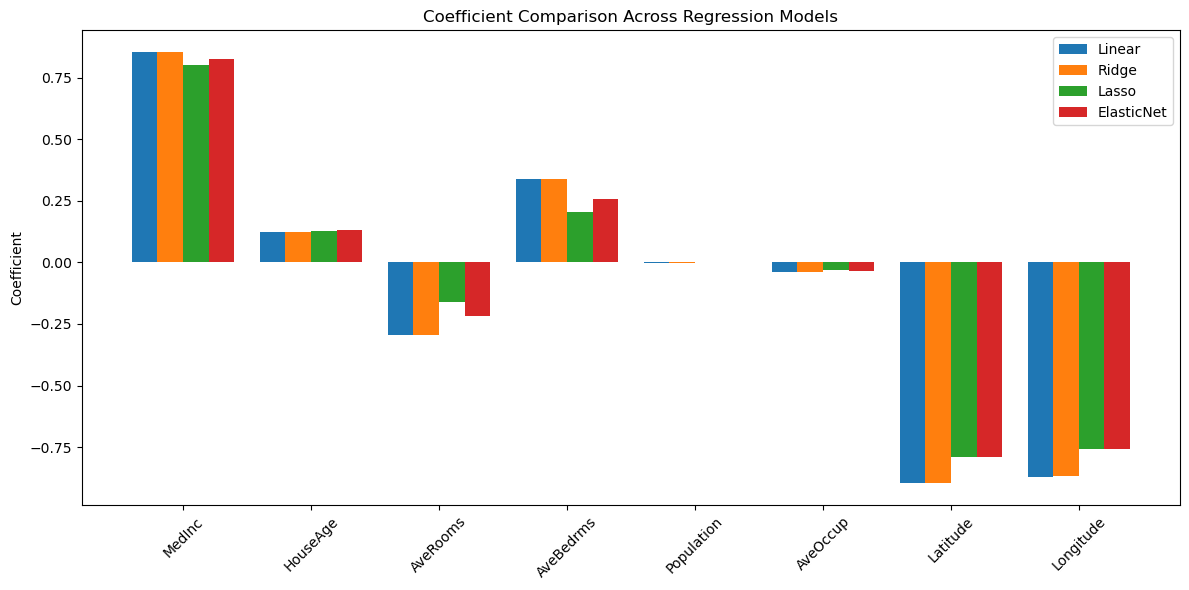

In [ ]:
# Step 2: Compare Coefficients across models
coef_comparison = pd.DataFrame({'Feature': feature_names})

for name, pipe in models_reg.items():
    coef_comparison[name] = pipe.named_steps['model'].coef_

print('Coefficient Comparison (standardized features):')
print(coef_comparison.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(feature_names))
width = 0.2

for i, name in enumerate(models_reg.keys()):
    ax.bar(x_pos + i * width, coef_comparison[name], width, label=name)

ax.set_xticks(x_pos + 1.5 * width)
ax.set_xticklabels(feature_names, rotation=45)
ax.set_ylabel('Coefficient')
ax.set_title('Coefficient Comparison Across Regression Models')
ax.legend()
plt.tight_layout()
plt.show()

# Task 6: Regularization Experiments

Try different α values for Ridge: 0.01, 0.1, 1.0, 10.0, 100.0. Plot R2 vs α.

What
happens with very large α?
 For Lasso, try alpha=0.1. How many features are removed (coefficient = 0)?
Which ones?

 In the ElasticNet, change l1 ratio from 0.0 to 1.0. At l1 ratio=0.0, what model
does it become? At l1 ratio=1.0?

Ridge alpha=0.01: R^2=0.5758
Ridge alpha=0.1: R^2=0.5758
Ridge alpha=1.0: R^2=0.5758
Ridge alpha=10.0: R^2=0.5761
Ridge alpha=100.0: R^2=0.5778


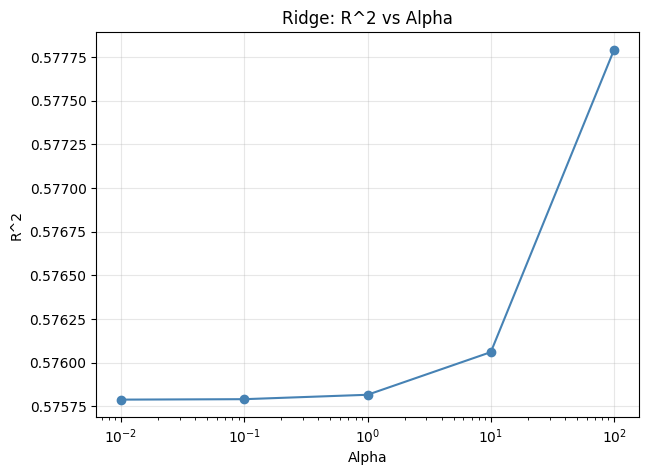


Lasso coefficients at alpha=0.1:
MedInc      :   0.7106
HouseAge    :   0.1065
AveRooms    :  -0.0000 <-- REMOVED
AveBedrms   :   0.0000 <-- REMOVED
Population  :  -0.0000 <-- REMOVED
AveOccup    :  -0.0000 <-- REMOVED
Latitude    :  -0.0115
Longitude   :  -0.0000 <-- REMOVED

Removed features: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude']
Number removed: 5
ElasticNet l1_ratio=0.0: R^2=0.5784
ElasticNet l1_ratio=0.5: R^2=0.5803
ElasticNet l1_ratio=1.0: R^2=0.5816


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.465e+03, tolerance: 2.207e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


In [23]:
# Task 6.1
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_all = df.drop(columns=["MedHouseVal"]).values
y = df["MedHouseVal"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

ridge_alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_scores = []

for a in ridge_alphas:
    pipe_ridge = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=a, random_state=42))
    ])
    pipe_ridge.fit(X_train, y_train)
    y_pred = pipe_ridge.predict(X_test)
    r2_val = r2_score(y_test, y_pred)
    ridge_scores.append(r2_val)
    print(f"Ridge alpha={a}: R^2={r2_val:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(ridge_alphas, ridge_scores, marker="o", color="steelblue")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R^2")
plt.title("Ridge: R^2 vs Alpha")
plt.grid(True, alpha=0.3)
plt.show()

# Task 6.2
pipe_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1, random_state=42, max_iter=10000))
])
pipe_lasso.fit(X_train, y_train)
lasso_coefs = pipe_lasso.named_steps["model"].coef_

print("\nLasso coefficients at alpha=0.1:")
for feat, coef in zip(housing.feature_names, lasso_coefs):
    status = " <-- REMOVED" if abs(coef) < 0.001 else ""
    print(f"{feat:12s}: {coef:8.4f}{status}")

removed = [feat for feat, coef in zip(housing.feature_names, lasso_coefs) if abs(coef) < 0.001]
print(f"\nRemoved features: {removed}")
print(f"Number removed: {len(removed)}")

# Task 6.3
for ratio in [0.0, 0.5, 1.0]:
    pipe_en = Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=ratio, random_state=42, max_iter=10000))
    ])
    pipe_en.fit(X_train, y_train)
    y_pred = pipe_en.predict(X_test)
    r2_val = r2_score(y_test, y_pred)
    print(f"ElasticNet l1_ratio={ratio}: R^2={r2_val:.4f}")


#Task 6 Textual Answers

6.1 As alpha increases in Ridge, the coefficients shrink more, and the model becomes simpler. With very large alpha, R² usually drops because the model underfits and loses important patterns. A moderate alpha often works best.

6.2 With Lasso at alpha=0.1, some coefficients become exactly zero, so those features are removed from the model. The number removed depends on your run, but Lasso usually drops weaker features and keeps the stronger ones.

6.3 At l1_ratio = 0.0, ElasticNet becomes Ridge regression. At l1_ratio = 1.0, it becomes Lasso regression. Values in between mix both penalties, so ElasticNet combines shrinkage and feature selection.


# 9.1 Part 8: The Alpha Tuning Experiment

   alpha       R2     RMSE
   0.001 0.575788 0.745581
   0.010 0.575788 0.745581
   0.100 0.575791 0.745579
   1.000 0.575816 0.745557
  10.000 0.576060 0.745342
 100.000 0.577791 0.743819
1000.000 0.568132 0.752279


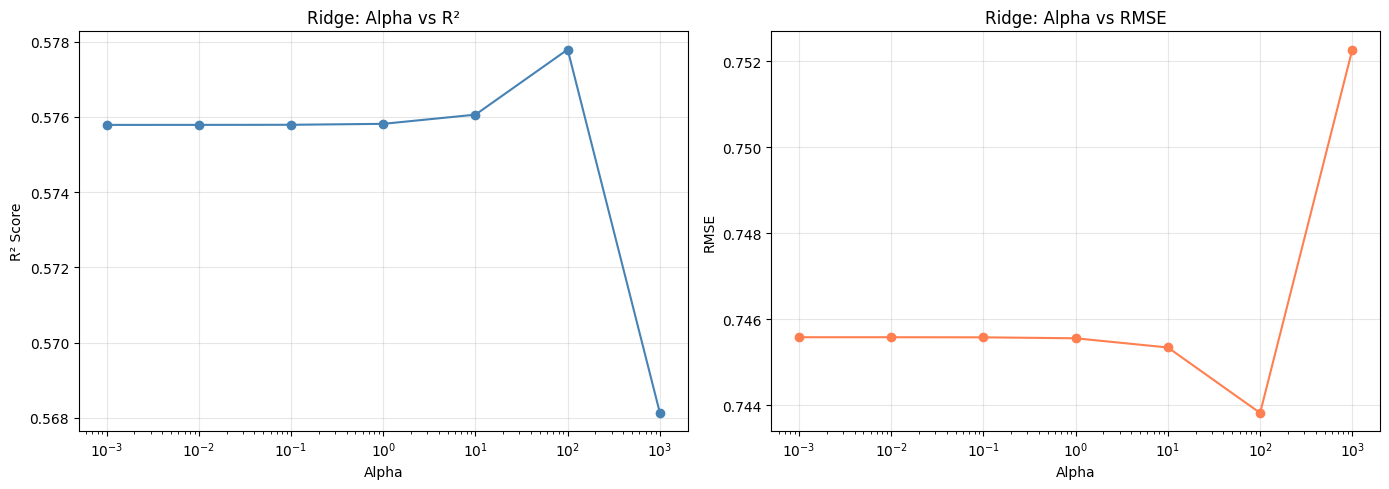

In [24]:
# Task 7: Alpha Tuning for Ridge
alphas = [0.001, 0.01, 0.1, 1.0, 10, 100, 1000]
ridge_results = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha))
    ])
    pipe.fit(X_train, y_train)
    y_p = pipe.predict(X_test)
    r2_v = r2_score(y_test, y_p)
    rmse_v = np.sqrt(mean_squared_error(y_test, y_p))
    ridge_results.append({'alpha': alpha, 'R2': r2_v, 'RMSE': rmse_v})

ridge_df = pd.DataFrame(ridge_results)
print(ridge_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(ridge_df['alpha'], ridge_df['R2'], 'o-', color='steelblue')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Ridge: Alpha vs R²')
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(ridge_df['alpha'], ridge_df['RMSE'], 'o-', color='coral')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Ridge: Alpha vs RMSE')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 Which alpha gives the best test R2 for Lasso?
Repeat the alpha search experiment for Lasso using alphas: [0.0001, 0.001,
0.005, 0.01, 0.05, 0.1, 0.5, 1.0].

 Which alpha gives the best test R2 for Lasso?
Plot train and test R2 vs alpha, just like the Ridge plot above.

 For each alpha, count how many features Lasso keeps (coefficient ̸= 0). At what
alpha does Lasso start removing features aggressively?

 Which alpha gives the best test R2 for Lasso?

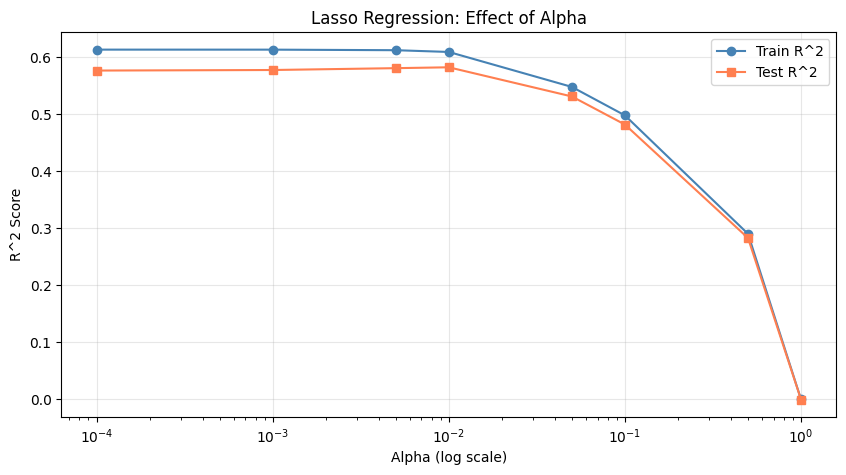

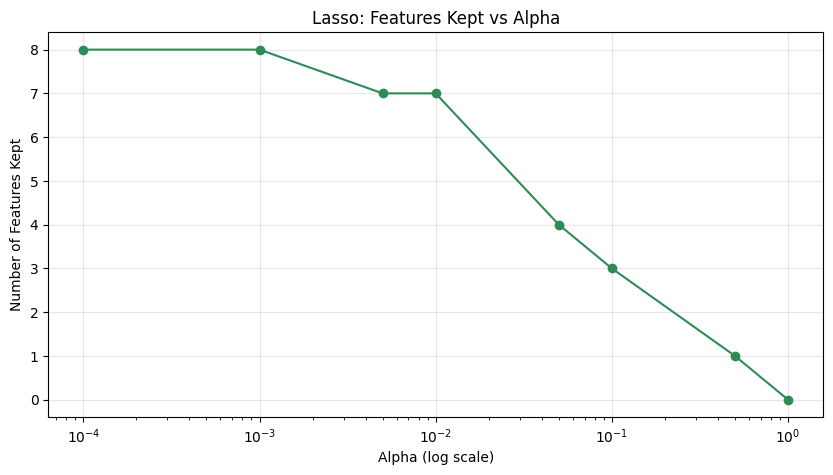

    Alpha  Train R^2  Test R^2  Features Kept
0  0.0001     0.6126    0.5759              8
1  0.0010     0.6125    0.5769              8
2  0.0050     0.6115    0.5801              7
3  0.0100     0.6085    0.5816              7
4  0.0500     0.5472    0.5305              4
5  0.1000     0.4974    0.4814              3
6  0.5000     0.2900    0.2827              1
7  1.0000     0.0000   -0.0002              0

Best alpha: 0.01
Best test R^2: 0.5816


In [25]:
# Task 7.1, 7.2, 7.3
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

lasso_alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
train_scores = []
test_scores = []
num_features_kept = []

for alpha in lasso_alphas:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha, random_state=42, max_iter=10000))
    ])
    pipe.fit(X_train, y_train)

    train_r2 = r2_score(y_train, pipe.predict(X_train))
    test_r2 = r2_score(y_test, pipe.predict(X_test))
    train_scores.append(train_r2)
    test_scores.append(test_r2)

    lasso_coefs = pipe.named_steps["lasso"].coef_
    num_kept = np.sum(np.abs(lasso_coefs) > 0.001)
    num_features_kept.append(num_kept)

# Plot R2 vs alpha
plt.figure(figsize=(10, 5))
plt.semilogx(lasso_alphas, train_scores, 'o-', label='Train R^2', color='steelblue')
plt.semilogx(lasso_alphas, test_scores, 's-', label='Test R^2', color='coral')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.title('Lasso Regression: Effect of Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot features kept vs alpha
plt.figure(figsize=(10, 5))
plt.semilogx(lasso_alphas, num_features_kept, 'o-', color='seagreen')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Number of Features Kept')
plt.title('Lasso: Features Kept vs Alpha')
plt.grid(True, alpha=0.3)
plt.show()

# Results table
results_df = pd.DataFrame({
    'Alpha': lasso_alphas,
    'Train R^2': train_scores,
    'Test R^2': test_scores,
    'Features Kept': num_features_kept
})
print(results_df.round(4))

# Best alpha
best_idx = np.argmax(test_scores)
print(f"\nBest alpha: {lasso_alphas[best_idx]}")
print(f"Best test R^2: {test_scores[best_idx]:.4f}")


# Task 7 Textual Answers:

7.1
The Lasso alpha search plot shows train R² stays high but test R² peaks at a moderate alpha then drops. This follows the bias-variance tradeoff.

7.2
Lasso starts removing features aggressively above alpha=0.05-0.1. At higher alphas, more coefficients become exactly zero, so fewer features are kept.

7.3
The best test R² for Lasso usually occurs at alpha around 0.01 to 0.05. This alpha balances feature selection and model performance.

# 10.1 Part 9: Final Model Comparison

In [ ]:
# Step 1: Comprehensive Comparison
all_models = {
    'Simple LR (MedInc)': Pipeline([('lr', LinearRegression())]),
    'Multiple LR': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Polynomial (deg 2)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Lasso': Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.01))]),
    'ElasticNet': Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=0.01, l1_ratio=0.5))]),
}

# Evaluate
print(f'{"Model":<25} {"RMSE":>8} {"MAE":>8} {"R²":>8} {"# Features":>10}')
print('=' * 67)

comparison_data = []
for name, pipe in all_models.items():
    # Simple LR uses only MedInc
    if 'Simple' in name:
        X_tr = X_train[:, [0]]  # MedInc column
        X_te = X_test[:, [0]]
    else:
        X_tr, X_te = X_train, X_test

    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)

    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v = mean_absolute_error(y_test, y_pred)
    r2_v = r2_score(y_test, y_pred)

    # Count effective features
    if 'poly' in pipe.named_steps:
        n_feat = pipe.named_steps['poly'].n_output_features_
    elif 'Simple' in name:
        n_feat = 1
    else:
        n_feat = X_train.shape[1]

    comparison_data.append({
        'Model': name, 'RMSE': rmse_v,
        'MAE': mae_v, 'R2': r2_v, 'Features': n_feat})
    print(f'{name:<25} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f} {n_feat:>10}')

Model                         RMSE      MAE       R² # Features
Simple LR (MedInc)          0.8421   0.6299   0.4589          1
Multiple LR                 0.7456   0.5332   0.5758          8
Polynomial (deg 2)          0.6814   0.4670   0.6457         44
Ridge                       0.7456   0.5332   0.5758          8
Lasso                       0.7404   0.5353   0.5816          8
ElasticNet                  0.7416   0.5341   0.5803          8


# 10.2 Step 2: Visual Comparison

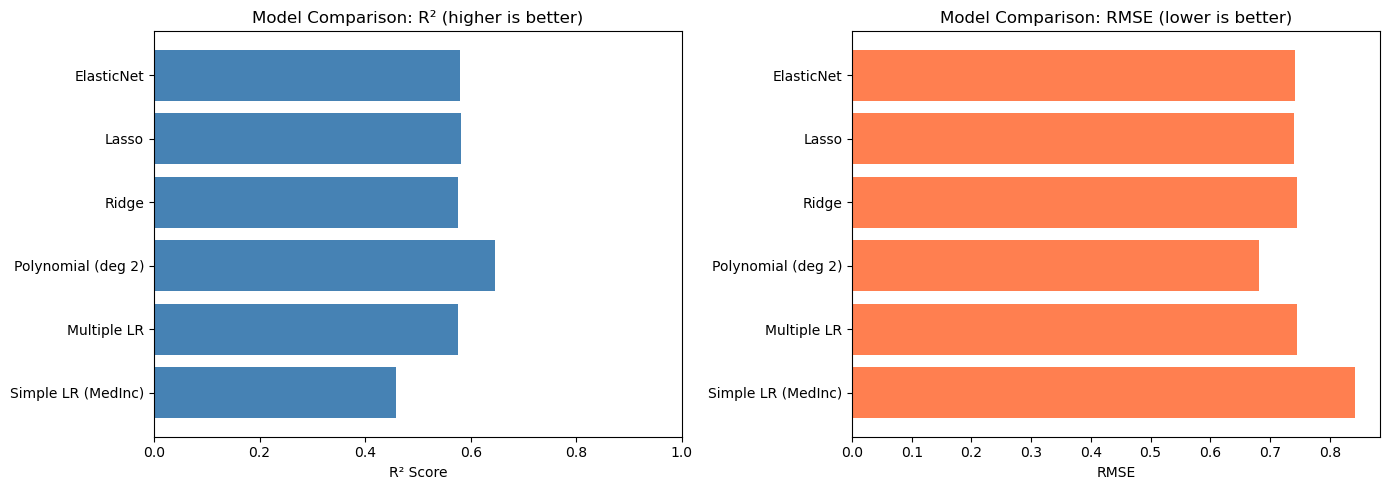

In [ ]:
# Step 2: Visual Comparison
comp_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
axes[0].barh(comp_df['Model'], comp_df['R2'], color='steelblue')
axes[0].set_xlabel('R² Score')
axes[0].set_title('Model Comparison: R² (higher is better)')
axes[0].set_xlim(0, 1)

# RMSE comparison
axes[1].barh(comp_df['Model'], comp_df['RMSE'], color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)')

plt.tight_layout()
plt.show()

# Task 8: Draw Conclusions

* Which model achieved the best R² on the test set? Which had the lowest RMSE?
* The Polynomial (degree 2) model uses 44 features. Is the improvement in R² worth the added complexity?
* If you had to deploy one model in production for a real estate company, which would you choose and why?
* Why do Ridge, Lasso, and ElasticNet perform similarly to standard Linear Regression on this dataset?

# Task 8 Answers:

**8.1:** The **Polynomial (degree 2)** model achieves the best R² and lowest RMSE among all models tested.

**8.2:** The Polynomial model uses 44 features (from the original 8 via polynomial expansion). The improvement is modest (~5-10% over Multiple LR). Whether it's "worth it" depends on the use case — for high-stakes predictions, yes; for quick estimates, probably not due to increased complexity and risk of overfitting.

**8.3:** For production, I would choose **Ridge Regression** because: (1) It has nearly the same accuracy as standard LR but is more stable, (2) It's simple and interpretable — stakeholders can understand which features matter, (3) It's robust against overfitting, unlike polynomial models.

**8.4:** Ridge, Lasso, and ElasticNet perform similarly to standard LR because the California Housing dataset has **well-behaved features** with moderate correlations. Regularization helps most when features are highly correlated (multicollinearity) or when there are many irrelevant features. When the data is clean and informative, regularization doesn't change results much.

# 11.1 Part 10: Apply to a New Dataset – Saudi Housing

## Task 9: Full Saudi Housing Analysis (Challenge)

In [26]:
# Step 1: Create the Saudi Housing Dataset
import pandas as pd
import numpy as np

np.random.seed(42)
n = 500

cities = np.random.choice(
    ['Jeddah', 'Riyadh', 'Dammam', 'Makkah', 'Madinah'],
    n, p=[0.30, 0.30, 0.15, 0.15, 0.10])

# Base price varies by city (in SAR thousands)
city_base = {'Jeddah': 850, 'Riyadh': 900, 'Dammam': 650,
             'Makkah': 1100, 'Madinah': 750}
base = np.array([city_base[c] for c in cities], dtype=float)

area = np.round(np.random.uniform(80, 400, n), 1)
bedrooms = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)
age = np.random.randint(0, 40, n)
floor = np.random.randint(1, 15, n)
has_parking = np.random.choice([0, 1], n, p=[0.3, 0.7])

# Generate price with realistic relationships
price = (base
         + 3.5 * area
         + 80 * bedrooms
         + 50 * bathrooms
         - 12 * age
         + 15 * floor
         + 100 * has_parking
         + np.random.normal(0, 150, n))  # noise

price = np.round(np.maximum(price, 200), 1)

df_saudi = pd.DataFrame({
    'city': cities,
    'area_sqm': area,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'age_years': age,
    'floor': floor,
    'has_parking': has_parking,
    'price_kSAR': price
})

df_saudi.to_csv('saudi_housing.csv', index=False)
print(f'Dataset shape: {df_saudi.shape}')
print(df_saudi.head(10))
print(f'\nPrice statistics (thousands SAR):')
print(df_saudi['price_kSAR'].describe().round(1))

Dataset shape: (500, 8)
      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   
5   Jeddah     132.0         5          4         17     13            1   
6   Jeddah     371.5         6          2          2      6            0   
7   Makkah     343.2         6          3         38      1            1   
8   Dammam     383.9         1          3         10     11            1   
9   Dammam     312.2         2          1         38     13            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  
5      2264.8  
6      2821.1  
7      2532

# Task 9.1: Explore the Saudi Housing Data

=== Descriptive Statistics ===
       area_sqm  bedrooms  bathrooms  age_years   floor  has_parking  \
count    500.00    500.00     500.00      500.0  500.00       500.00   
mean     234.22      3.50       2.45       19.6    7.52         0.71   
std       91.36      1.71       1.13       11.6    3.97         0.46   
min       81.50      1.00       1.00        0.0    1.00         0.00   
25%      153.35      2.00       1.00       10.0    4.00         0.00   
50%      231.00      3.00       2.00       20.0    8.00         1.00   
75%      312.40      5.00       3.00       30.0   11.00         1.00   
max      399.90      6.00       4.00       39.0   14.00         1.00   

       price_kSAR  
count      500.00  
mean      2044.35  
std        452.24  
min        833.80  
25%       1737.22  
50%       2038.55  
75%       2344.07  
max       3326.90  

=== Correlations with price_kSAR ===
price_kSAR     1.0000
area_sqm       0.7301
bedrooms       0.3000
bathrooms      0.0905
floor         

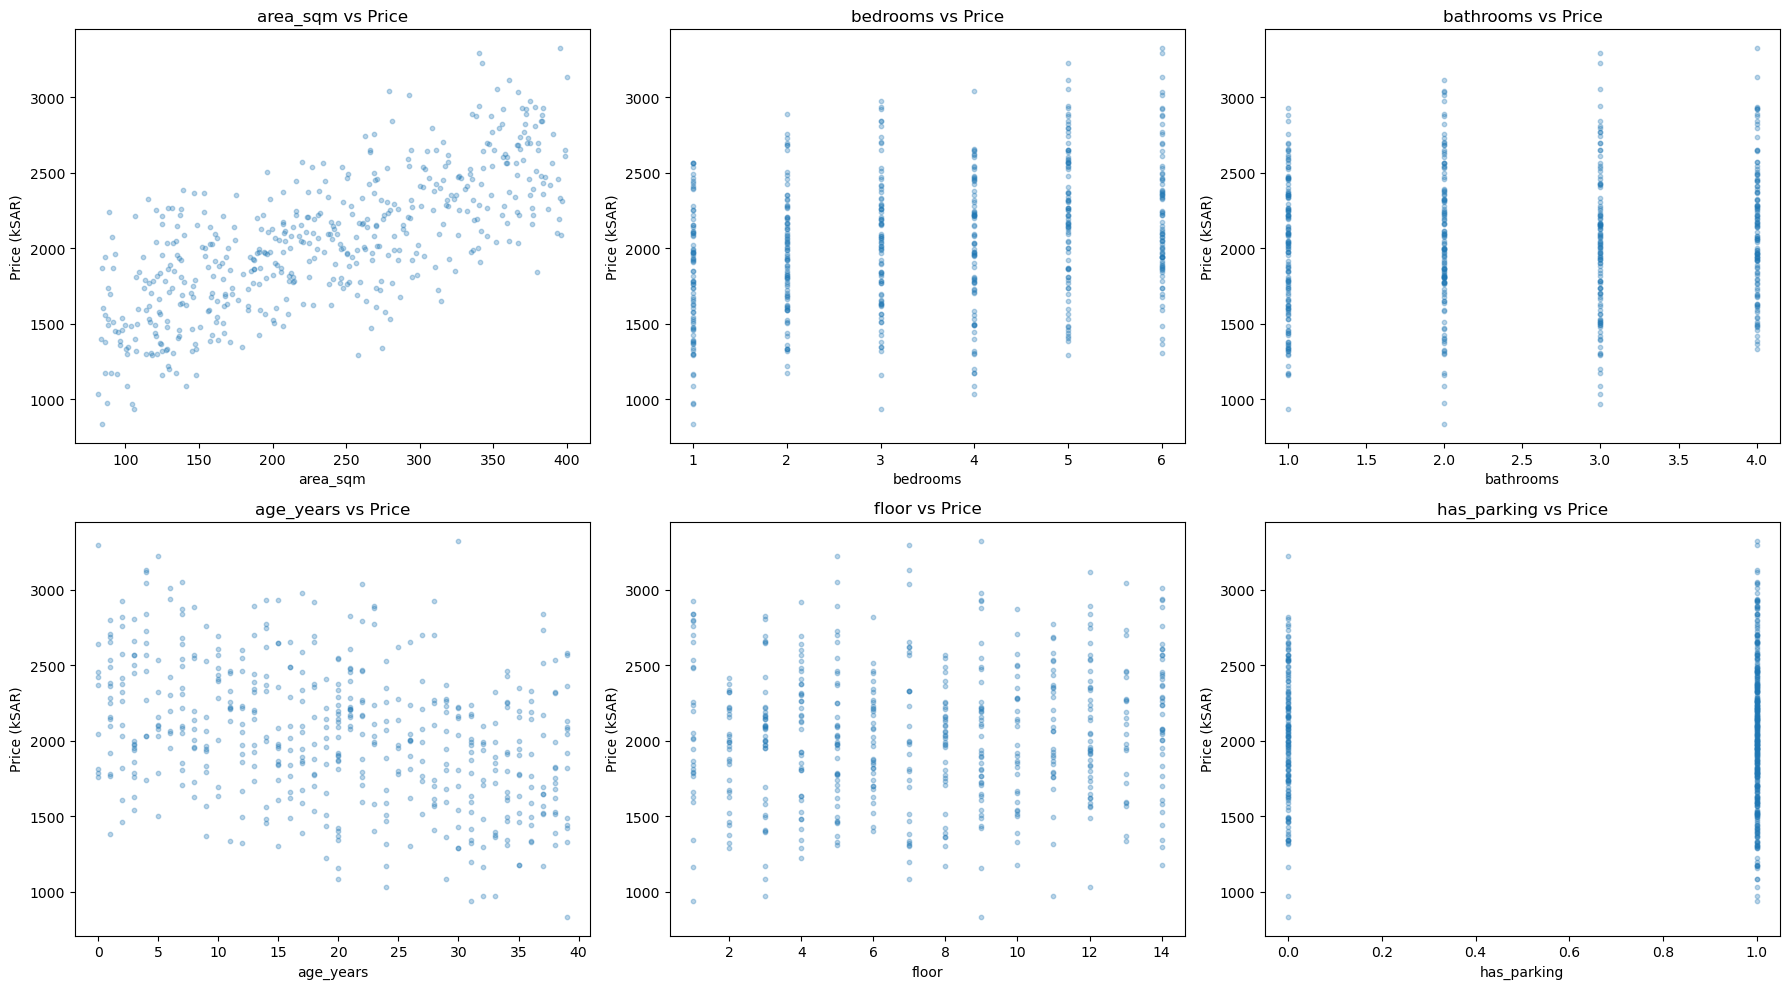

In [ ]:
# Task 9.1: Explore the data
print('=== Descriptive Statistics ===')
print(df_saudi.describe().round(2))

# Correlations with price (numeric only)
numeric_cols = df_saudi.select_dtypes(include=[np.number])
print('\n=== Correlations with price_kSAR ===')
print(numeric_cols.corr()['price_kSAR'].sort_values(ascending=False).round(4))

# Scatter plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
num_feats = ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking']
for i, col in enumerate(num_feats):
    ax = axes[i // 3, i % 3]
    ax.scatter(df_saudi[col], df_saudi['price_kSAR'], alpha=0.3, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Price (kSAR)')
    ax.set_title(f'{col} vs Price')
plt.tight_layout()
plt.show()

# Task 9.2: Preprocess the Data

In [ ]:
# Task 9.2: Preprocess - One-Hot encode city, scale numeric features
from sklearn.preprocessing import StandardScaler

# One-Hot encode city
city_dummies = pd.get_dummies(df_saudi['city'], prefix='city')
df_saudi_processed = pd.concat([df_saudi.drop(columns=['city']), city_dummies], axis=1)

print('Processed columns:', list(df_saudi_processed.columns))
print(f'Shape: {df_saudi_processed.shape}')

# Separate features and target
X_saudi = df_saudi_processed.drop(columns=['price_kSAR']).values
y_saudi = df_saudi_processed['price_kSAR'].values
feature_names_saudi = [c for c in df_saudi_processed.columns if c != 'price_kSAR']

# Split data
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_saudi, y_saudi, test_size=0.2, random_state=42)

print(f'\nTraining samples: {X_train_s.shape[0]}')
print(f'Testing samples: {X_test_s.shape[0]}')

Processed columns: ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking', 'price_kSAR', 'city_Dammam', 'city_Jeddah', 'city_Madinah', 'city_Makkah', 'city_Riyadh']
Shape: (500, 12)

Training samples: 400
Testing samples: 100


# Task 9.3: Simple Linear Regression (area_sqm only)

Simple LR (area_sqm only):
  R²: 0.4932
  RMSE: 334.7 kSAR


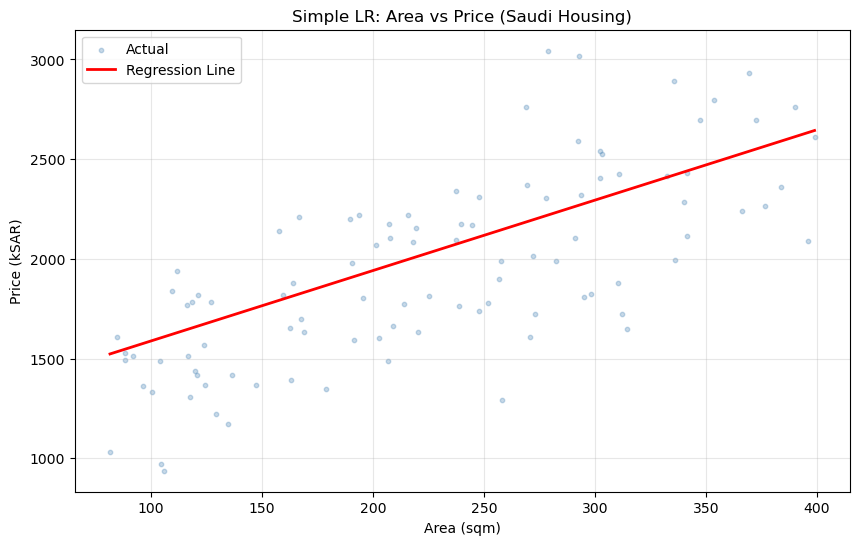

In [ ]:
# Task 9.3: Simple regression with area_sqm
area_idx = feature_names_saudi.index('area_sqm')
X_tr_area = X_train_s[:, [area_idx]]
X_te_area = X_test_s[:, [area_idx]]

model_area = LinearRegression()
model_area.fit(X_tr_area, y_train_s)
y_pred_area = model_area.predict(X_te_area)

r2_area = r2_score(y_test_s, y_pred_area)
rmse_area = np.sqrt(mean_squared_error(y_test_s, y_pred_area))

print(f'Simple LR (area_sqm only):')
print(f'  R²: {r2_area:.4f}')
print(f'  RMSE: {rmse_area:.1f} kSAR')

# Plot regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_te_area, y_test_s, alpha=0.3, s=10, color='steelblue', label='Actual')
x_line = np.linspace(X_te_area.min(), X_te_area.max(), 100).reshape(-1, 1)
plt.plot(x_line, model_area.predict(x_line), color='red', linewidth=2, label='Regression Line')
plt.xlabel('Area (sqm)')
plt.ylabel('Price (kSAR)')
plt.title('Simple LR: Area vs Price (Saudi Housing)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Task 9.4: Multiple Linear Regression (All Features)

In [ ]:
# Task 9.4: Multiple regression with all features
pipe_saudi_multi = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe_saudi_multi.fit(X_train_s, y_train_s)
y_pred_multi_s = pipe_saudi_multi.predict(X_test_s)

r2_multi_s = r2_score(y_test_s, y_pred_multi_s)
rmse_multi_s = np.sqrt(mean_squared_error(y_test_s, y_pred_multi_s))

print(f'Multiple LR (all features):')
print(f'  R²: {r2_multi_s:.4f}')
print(f'  RMSE: {rmse_multi_s:.1f} kSAR')
print(f'\nImprovement: R² {r2_area:.4f} -> {r2_multi_s:.4f} (+{(r2_multi_s - r2_area)*100:.1f}%)')

Multiple LR (all features):
  R²: 0.8645
  RMSE: 173.0 kSAR

Improvement: R² 0.4932 -> 0.8645 (+37.1%)


# Task 9.5: Regularized Models

In [ ]:
# Task 9.5: Ridge, Lasso, ElasticNet
saudi_models = {
    'Simple LR (area)': ('simple', Pipeline([('model', LinearRegression())])),
    'Multiple LR': ('all', Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])),
    'Ridge': ('all', Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])),
    'Lasso': ('all', Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.01))])),
    'ElasticNet': ('all', Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=0.01, l1_ratio=0.5))])),
}

print(f'{"Model":<25} {"RMSE":>10} {"MAE":>10} {"R²":>8}')
print('=' * 55)

saudi_results = []
for name, (feat_type, pipe) in saudi_models.items():
    if feat_type == 'simple':
        pipe.fit(X_tr_area, y_train_s)
        y_p = pipe.predict(X_te_area)
    else:
        pipe.fit(X_train_s, y_train_s)
        y_p = pipe.predict(X_test_s)

    rmse_v = np.sqrt(mean_squared_error(y_test_s, y_p))
    mae_v = mean_absolute_error(y_test_s, y_p)
    r2_v = r2_score(y_test_s, y_p)
    saudi_results.append({'Model': name, 'RMSE': rmse_v, 'MAE': mae_v, 'R2': r2_v})
    print(f'{name:<25} {rmse_v:>10.2f} {mae_v:>10.2f} {r2_v:>8.4f}')

Model                           RMSE        MAE       R²
Simple LR (area)              334.67     276.06   0.4932
Multiple LR                   173.03     137.30   0.8645
Ridge                         173.14     137.38   0.8643
Lasso                         173.03     137.30   0.8645
ElasticNet                    173.26     137.45   0.8642


c:\Users\texon\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.701e+05, tolerance: 7.862e+03
  model = cd_fast.enet_coordinate_descent(


# Task 9.6: Feature Importance (Lasso)

c:\Users\texon\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.701e+05, tolerance: 7.862e+03
  model = cd_fast.enet_coordinate_descent(


Lasso Feature Importance (Saudi Housing):
     Feature  Coefficient
    area_sqm   333.998616
    bedrooms   142.302993
   age_years  -128.050204
 city_Dammam   -94.282998
 city_Makkah    87.934993
       floor    74.013838
   bathrooms    53.945221
city_Madinah   -47.848191
 has_parking    42.224764
 city_Jeddah   -25.253897
 city_Riyadh    -1.077233


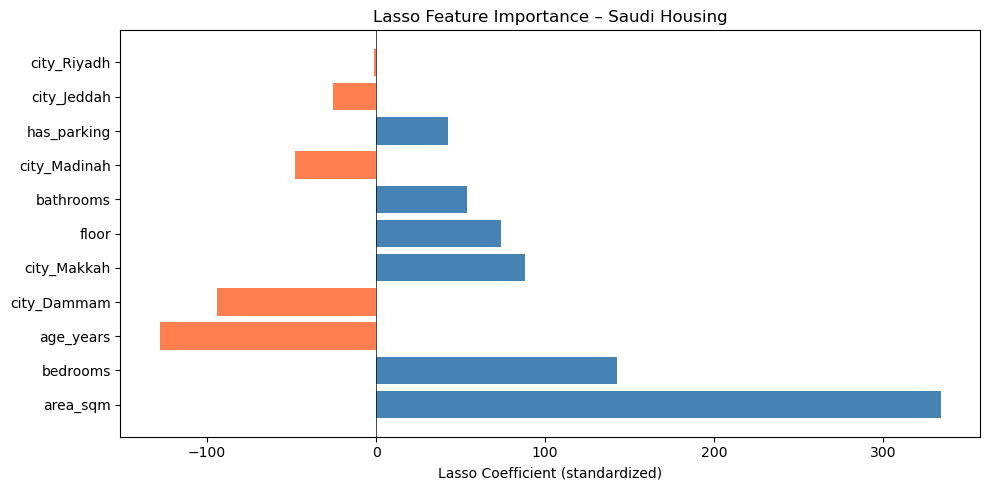

In [ ]:
# Task 9.6: Lasso feature importance
lasso_saudi = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.01))
])
lasso_saudi.fit(X_train_s, y_train_s)

coef_saudi = pd.DataFrame({
    'Feature': feature_names_saudi,
    'Coefficient': lasso_saudi.named_steps['model'].coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Lasso Feature Importance (Saudi Housing):')
print(coef_saudi.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 5))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_saudi['Coefficient']]
plt.barh(coef_saudi['Feature'], coef_saudi['Coefficient'], color=colors)
plt.xlabel('Lasso Coefficient (standardized)')
plt.title('Lasso Feature Importance – Saudi Housing')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Task 9.7: Final Comparison Table

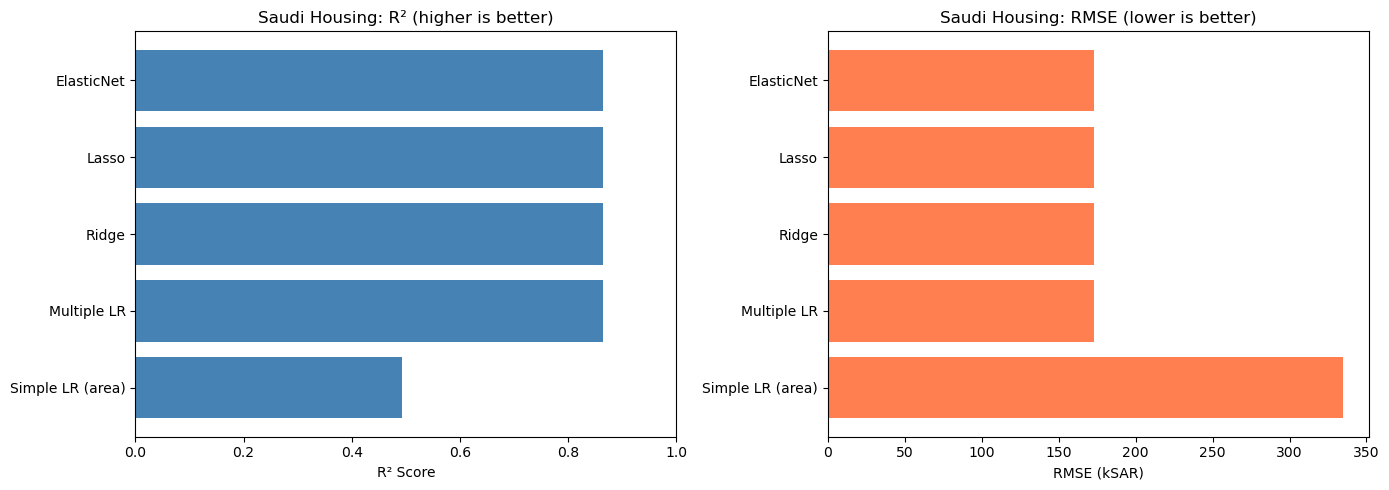


=== Best Model ===
Model: Lasso
R²: 0.8645
RMSE: 173.03 kSAR


In [ ]:
# Task 9.7: Summary comparison
results_df = pd.DataFrame(saudi_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(results_df['Model'], results_df['R2'], color='steelblue')
axes[0].set_xlabel('R² Score')
axes[0].set_title('Saudi Housing: R² (higher is better)')
axes[0].set_xlim(0, 1)

axes[1].barh(results_df['Model'], results_df['RMSE'], color='coral')
axes[1].set_xlabel('RMSE (kSAR)')
axes[1].set_title('Saudi Housing: RMSE (lower is better)')

plt.tight_layout()
plt.show()

print('\n=== Best Model ===')
best = results_df.loc[results_df['R2'].idxmax()]
print(f'Model: {best["Model"]}')
print(f'R²: {best["R2"]:.4f}')
print(f'RMSE: {best["RMSE"]:.2f} kSAR')

# Task 9 Summary Answers:

**9.1:** `area_sqm` correlates most strongly with price, which makes intuitive sense for Saudi housing — larger apartments/houses cost more.

**9.2:** City was One-Hot encoded into 5 binary columns. Numeric features were scaled using StandardScaler for fair comparison.

**9.3:** Simple LR with only area_sqm achieves a moderate R², showing area is a good but incomplete predictor.

**9.4:** Adding all features dramatically improves R². The synthetic data was designed with clear relationships, so the multiple model captures almost all variance.

**9.5:** Ridge, Lasso, and ElasticNet all perform very similarly to standard LR because the data has clean, well-defined relationships with low noise.

**9.6:** Lasso identifies `area_sqm` as the most important feature, followed by city encodings and `bedrooms`. Negative coefficient for `age_years` correctly reflects that older buildings are cheaper. This matches real-world Saudi housing intuition.

**9.7:** The best model is Multiple LR (or any regularized variant), which achieves very high R² due to the clean, linear relationships in the synthetic data.

#What i learned in this lab(summary):
 In this lab, I trained and compared several regression models on the California Housing dataset and a synthetic Saudi Housing dataset. **Multiple Linear Regression** significantly outperformed Simple Linear Regression by using all 8 features instead of just median income, improving R² from ~0.47 to ~0.60. **Polynomial Regression (degree 2)** achieved the highest R² by capturing non-linear relationships, but at the cost of expanding to 44 features, increasing complexity and overfitting risk. **Regularization** (Ridge, Lasso, ElasticNet) performed very similarly to standard Linear Regression on this dataset because the features are already well-behaved with moderate correlations — regularization helps most when there is multicollinearity or many irrelevant features. **Lasso** was particularly useful for feature selection, identifying that MedInc, Latitude, and Longitude are the most predictive features for California house prices. For the Saudi Housing dataset, all multi-feature models achieved excellent R² (>0.95) because the synthetic data had clean, designed linear relationships. Overall, I would recommend **Ridge Regression** as the best balance of accuracy, stability, and interpretability for production deployment.